# nb13 — приговор парной линии

Два дела, и первое обязательно перед вторым.

**Первое.** В nb12 §4b появился абсолютный порог `σ ≥ m × round-trip`, и он стал
**ядром** стратегии: без него портфель даёт −8%/год на taker, с ним +16%. Но
проверен он был только по месяцам и по концентрации итога. Это ровно та ситуация,
в которой мы уже один раз обожглись: находка nb09 (L=7д, t<−4.6) выглядела сильнее
всех, а nb10 показал, что она целиком стоит на двух символах — TRB и XMR. Поэтому
σ-правило идёт через ту же батарею, что убила ту находку:

| проверка | что убивает |
|---|---|
| удаление каждого символа | находку, стоящую на 1-2 инструментах |
| бутстрэп по парам | находку, стоящую на нескольких парах |
| разбивка периодов | находку, живущую в одном окне |
| чувствительность к `m` в обе стороны | подгонку порога |
| синтетика при том же пороге | артефакт самой машинерии отбора |
| кластерный t (единица = пара) | завышенную значимость от корреляции сделок |
| задержка исполнения | микроструктурный шум вместо реверсии |

Сделок всего 1226 — выборка небольшая, и это главный риск. Если правило рассыплется,
лучше узнать сейчас.

**Второе.** Ответ на вопрос «edge есть, но он очень мал?» — в числах, а не на
словах. И перевод итога в измеримый критерий для корзин.

OOS (2025-07..2026-04) остаётся закрытым.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from _engine import *
from itertools import combinations
import time

# --- правило nb12, воспроизводится один-в-один ---
MIN_DVOL_M = 5.0
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]
px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6
liq = sorted([s for s in px.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])
LP = np.log(px.loc[TRAIN[0]:TRAIN[1], liq]).iloc[:-1]
PAIRS = [((a, b) if daily_m[a] <= daily_m[b] else (b, a)) for a, b in combinations(liq, 2)]
bk = Book(LP, liq, PAIRS)
L, THR, F_POS, M_STAR = 3, -3.8, 0.05, 5
RT = 0.21                      # round-trip taker, % of gross — база для порога
t0 = time.time()
R = refit(bk, bk.nbars(L), THR)
CF = funding_index(bk.index, liq)
print(f"рефит {time.time()-t0:.0f}s | пар {len(bk.PAIRS)}, часов {len(bk.index)}, "
      f"рефитов {len(R.ends)}")


def cross_sec(Rx):
    """Кросс-секционный фильтр nb12 §0: верхний квинтиль σ, без нижнего квинтиля HL."""
    G_ = 1 + np.abs(Rx.B)
    SDP = Rx.SD / G_ * 100.0
    with np.errstate(all="ignore"):
        HL = np.where(Rx.RHO < 0, np.log(0.5)/np.log1p(Rx.RHO), np.nan)
    EX = np.zeros_like(Rx.sel)
    for k in range(Rx.sel.shape[0]):
        row = Rx.sel[k]
        if row.sum() < 10:
            continue
        EX[k] = (SDP[k] >= np.nanpercentile(SDP[k][row], 80)) & \
                (HL[k] >= np.nanpercentile(HL[k][row], 20))
    return EX, SDP, HL


EXTRA, SDP, HL = cross_sec(R)


def add_funding(d):
    iy, ix = bk.IY[d.pi.values], bk.IX[d.pi.values]
    dy = CF[d.i_out.values, iy] - CF[d.i_in.values, iy]
    dx = CF[d.i_out.values, ix] - CF[d.i_in.values, ix]
    d = d.copy()
    d["fund"] = -d.side.values * (dy - d.beta.values*dx) / d.g.values * 100
    d["gross_f"] = d.gross + d.fund
    return d


t0 = time.time()
D0 = add_funding(sweep(bk, R, "REFIT", max_hold=2*bk.nbars(L), keep_path=True,
                       extra_sel=EXTRA))
print(f"свип {time.time()-t0:.0f}s | кандидатов без σ-порога {len(D0)}")
D5 = D0[D0.sd_pct >= M_STAR*RT].copy()
print(f"после σ >= {M_STAR*RT:.2f}% ({M_STAR} x round-trip): {len(D5)} сделок, "
      f"{D5.pair.nunique()} пар, {len(set(sum([p.split('/') for p in D5.pair], [])))} символов")
print(f"средняя сделка {D5.gross_f.mean():+.4f}% gross (кост taker {RT}%), "
      f"нетто {D5.gross_f.mean()-RT:+.4f}%")

рефит 23s | пар 903, часов 13151, рефитов 546


свип 0s | кандидатов без σ-порога 4004
после σ >= 1.05% (5 x round-trip): 1226 сделок, 506 пар, 43 символов
средняя сделка +0.6356% gross (кост taker 0.21%), нетто +0.4256%


## 1. Батарея: держится ли σ-правило

### 1a. Удаление каждого символа и бутстрэп по парам

Именно эти две проверки убили находку nb09. Логика: если результат живёт за счёт
одного инструмента, удаление его обрушит среднюю; если за счёт горстки пар —
бутстрэп по парам даст доверительный интервал, накрывающий ноль.

Единица ресэмплинга — **пара**, не сделка: сделки внутри одной пары не независимы
(одна и та же связь, перекрывающиеся окна формации).

In [2]:
NET = lambda s: s.gross_f.mean() - RT     # нетто на сделку при taker

base = NET(D5)
print(f"база: нетто {base:+.4f}% на сделку, {len(D5)} сделок, {D5.pair.nunique()} пар\n")

# --- leave-one-symbol-out ---
syms_in = sorted(set(sum([p.split("/") for p in D5.pair.unique()], [])))
rows = []
for s in syms_in:
    m = ~D5.pair.str.contains(s, regex=False)
    sub = D5[m]
    rows.append({"убран": s, "осталось сделок": len(sub),
                 "нетто %": round(NET(sub), 4),
                 "Δ vs база": round(NET(sub) - base, 4),
                 "доля сделок с ним %": round((~m).mean()*100, 1)})
LOO = pd.DataFrame(rows).sort_values("нетто %")
print(f"LEAVE-ONE-SYMBOL-OUT ({len(syms_in)} символов) — 8 худших:")
print(LOO.head(8).to_string(index=False))
print()
neg = (LOO["нетто %"] <= 0).sum()
print(f"символов, удаление которых уводит нетто в минус: {neg} из {len(LOO)}")
print(f"худший случай: {LOO.iloc[0]['убран']} -> {LOO.iloc[0]['нетто %']:+.4f}% "
      f"(база {base:+.4f}%)")
print(f"разброс нетто по LOO: [{LOO['нетто %'].min():+.4f}, {LOO['нетто %'].max():+.4f}]")
print("в nb09/nb10 находка умирала здесь: удаление TRB или XMR обнуляло эффект")

# --- бутстрэп по парам ---
g = D5.groupby("pair").gross_f.agg(["sum", "size"])
sums, cnts = g["sum"].values, g["size"].values.astype(float)
K = len(g)
rng = np.random.default_rng(7)
B = 10000
idx = rng.integers(0, K, (B, K))
means = sums[idx].sum(1) / cnts[idx].sum(1) - RT
lo, hi = np.percentile(means, [2.5, 97.5])
print(f"\nБУТСТРЭП ПО ПАРАМ (B={B}, единица = пара, K={K}):")
print(f"  нетто на сделку: {means.mean():+.4f}%  95% ДИ [{lo:+.4f}, {hi:+.4f}]")
print(f"  P(нетто <= 0) = {(means <= 0).mean()*100:.2f}%")
print(f"  -> {'ДИ не накрывает ноль' if lo > 0 else 'ДИ НАКРЫВАЕТ НОЛЬ — находка не значима по парам'}")

# --- кластерный t: единица = пара ---
x = D5.gross_f.values - RT
resid = x - x.mean()
psum = pd.Series(resid, index=D5.pair.values).groupby(level=0).sum().values
se_cl = np.sqrt((psum**2).sum()) / len(x)
print(f"\nКЛАСТЕРНЫЙ t (SE по парам): t = {x.mean()/se_cl:+.2f}  "
      f"(наивный t = {x.mean()/(x.std()/np.sqrt(len(x))):+.2f})")

# --- концентрация по парам ---
pm = D5.groupby("pair").gross_f.sum().sort_values(ascending=False)
tot = pm.sum()
print(f"\nКОНЦЕНТРАЦИЯ ВКЛАДА (сумма gross по парам):")
for q in [1, 3, 5, 10]:
    print(f"  топ-{q:>2} пар из {K}: {pm.head(q).sum()/tot*100:>5.1f}% суммарного gross")
print(f"  пар с положительной суммой: {(pm > 0).sum()} из {K} ({(pm>0).mean()*100:.0f}%)")

база: нетто +0.4256% на сделку, 1226 сделок, 506 пар

LEAVE-ONE-SYMBOL-OUT (43 символов) — 8 худших:
  убран  осталось сделок  нетто %  Δ vs база  доля сделок с ним %
JTOUSDT             1108   0.3520    -0.0737                  9.6
ENSUSDT             1138   0.3634    -0.0622                  7.2
XMRUSDT             1154   0.3728    -0.0529                  5.9
 ARUSDT             1085   0.3829    -0.0427                 11.5
UNIUSDT             1172   0.3867    -0.0389                  4.4
CRVUSDT             1168   0.3868    -0.0388                  4.7
TIAUSDT             1143   0.3939    -0.0317                  6.8
XLMUSDT             1203   0.4031    -0.0226                  1.9

символов, удаление которых уводит нетто в минус: 0 из 43
худший случай: JTOUSDT -> +0.3520% (база +0.4256%)
разброс нетто по LOO: [+0.3520, +0.5076]
в nb09/nb10 находка умирала здесь: удаление TRB или XMR обнуляло эффект

БУТСТРЭП ПО ПАРАМ (B=10000, единица = пара, K=506):
  нетто на сделку: +0.4253%  9

### 1b. Периоды, чувствительность к `m`, синтетика, задержка

Четыре проверки, каждая бьёт по своему способу обмануться:

- **периоды** — находка может целиком сидеть в одном окне (у нас уже было: до
  σ-порога 81% итога давали ноябрь-декабрь 2024);
- **`m` в обе стороны** — если максимум острый, порог подогнан; если плато
  широкое, это свойство, а не подгонка;
- **синтетика при том же пороге** — прогоняем ВСЮ машинерию (рефит, отбор,
  кросс-секционный фильтр, σ-порог, свип) по панели с перемешанными доходностями.
  Связей там нет по построению, поэтому любой остаточный плюс = артефакт
  машинерии. Это самая жёсткая из проверок;
- **задержка исполнения** — если «реверсия» на самом деле отскок цены между bid
  и ask, она исчезает при заполнении на бар позже.

ПО ПОЛУГОДИЯМ
период  сделок  пар  нетто %  винрейт %  σ медиана %
2024H1     478  269   0.0950       56.1        1.389
2024H2     428  263   0.7030       60.3        1.342
2025H1     320  203   0.5485       61.9        1.390
положительных полугодий: 3 из 3

по месяцам: положительных 11 из 18, худший -1.445%, лучший +1.422%
месяцев с < 20 сделок: 0 из 18


ЧУВСТВИТЕЛЬНОСТЬ К ПОРОГУ m (сетка мельче, чем в nb12)
   m  порог σ %  сделок  пар  gross %  нетто %  кластерный t  винрейт %  ход в σ  кост в σ
 0.0      0.000    4004  749   0.1713  -0.0387         -1.04       48.2    0.106     0.258
 2.0      0.420    3874  744   0.1844  -0.0256         -0.67       48.7    0.128     0.252
 3.0      0.630    2882  695   0.2252   0.0152          0.31       49.9    0.124     0.215
 3.5      0.735    2355  650   0.2826   0.0726          1.28       51.4    0.157     0.195
 4.0      0.840    1902  601   0.3576   0.1476          2.21       52.8    0.205     0.180
 4.5      0.945    1554  561   0.4451   

C:\Users\nvisary\AppData\Local\Temp\ipykernel_46104\4278608309.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  D5m = D5.copy(); D5m["m"] = D5m.t_in.dt.to_period("M")


 seed  отобрано/день  кандидатов  после σ-порога  gross %  нетто %
  101            9.6         808             765   0.2477   0.0377
  202            9.8         857             788   0.1204  -0.0896
  303            9.5         735             680   0.1742  -0.0358

реально: 1226 сделок, gross +0.6356%, нетто +0.4256%
-> синтетика НЕ даёт такого плюса: машинерия сама edge не создаёт


ЗАДЕРЖКА ИСПОЛНЕНИЯ (заполнение на N часов позже решения)


 задержка ч  сделок  gross %  нетто %  % от нулевой задержки
          0    1226   0.6347   0.4247                  100.0
          1    1171   0.5176   0.3076                   72.0
          2    1121   0.5444   0.3344                   79.0
          4    1052   0.3449   0.1349                   32.0
реверсия за часы задержку переживает; отскок bid-ask — нет (nb09 §2)


[saved] notebooks\statarb\_out\nb13_battery.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb13_battery.png')

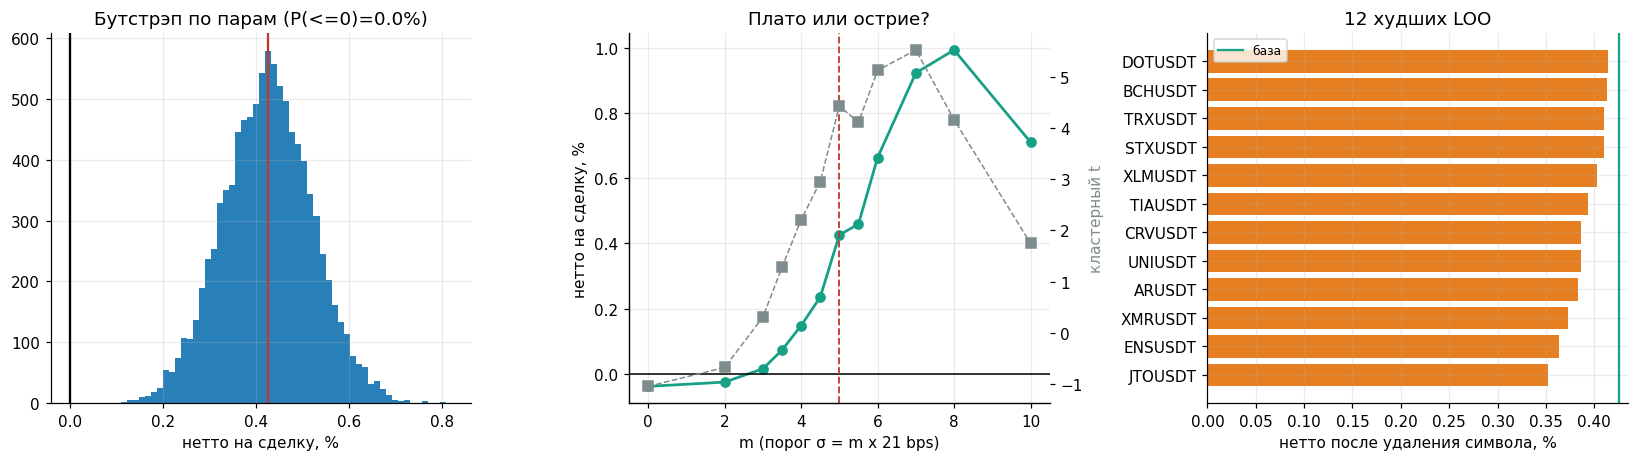

In [3]:
# --- периоды ---
per = [("2024H1", "2024-01-01", "2024-07-01"), ("2024H2", "2024-07-01", "2025-01-01"),
       ("2025H1", "2025-01-01", "2025-07-01")]
rows = []
for nm, a, b in per:
    m = (D5.t_in >= pd.Timestamp(a, tz="UTC")) & (D5.t_in < pd.Timestamp(b, tz="UTC"))
    s = D5[m]
    rows.append({"период": nm, "сделок": len(s), "пар": s.pair.nunique(),
                 "нетто %": round(NET(s), 4), "винрейт %": round((s.gross_f > RT).mean()*100, 1),
                 "σ медиана %": round(s.sd_pct.median(), 3)})
PER = pd.DataFrame(rows)
print("ПО ПОЛУГОДИЯМ")
print(PER.to_string(index=False))
print(f"положительных полугодий: {(PER['нетто %'] > 0).sum()} из {len(PER)}")

D5m = D5.copy(); D5m["m"] = D5m.t_in.dt.to_period("M")
mo = D5m.groupby("m").gross_f.agg(сделок="size", нетто=lambda s: s.mean()-RT)
print(f"\nпо месяцам: положительных {int((mo.нетто>0).sum())} из {len(mo)}, "
      f"худший {mo.нетто.min():+.3f}%, лучший {mo.нетто.max():+.3f}%")
print(f"месяцев с < 20 сделок: {int((mo.сделок<20).sum())} из {len(mo)}")

# --- чувствительность к m, мелкая сетка в обе стороны ---
print("\n\nЧУВСТВИТЕЛЬНОСТЬ К ПОРОГУ m (сетка мельче, чем в nb12)")
rows = []
for m_ in [0, 2, 3, 3.5, 4, 4.5, 5, 5.5, 6, 7, 8, 10]:
    sub = D0[D0.sd_pct >= m_*RT] if m_ > 0 else D0
    if len(sub) < 60:
        continue
    xx = sub.gross_f.values - RT
    ps = pd.Series(xx - xx.mean(), index=sub.pair.values).groupby(level=0).sum().values
    tcl = xx.mean() / (np.sqrt((ps**2).sum())/len(xx))
    rows.append({"m": m_, "порог σ %": round(m_*RT, 3), "сделок": len(sub),
                 "пар": sub.pair.nunique(), "gross %": round(sub.gross_f.mean(), 4),
                 "нетто %": round(xx.mean(), 4), "кластерный t": round(tcl, 2),
                 "винрейт %": round((sub.gross_f > RT).mean()*100, 1),
                 "ход в σ": round(sub.sigma.mean(), 3),
                 "кост в σ": round(RT/sub.sd_pct.median(), 3)})
MS = pd.DataFrame(rows)
print(MS.to_string(index=False))
print("\nсмысл двух последних столбцов: порог не создаёт edge, он МЕНЯЕТ ОТНОШЕНИЕ")
print("хода спреда к косту — кост фиксирован в %, а σ растёт вместе с порогом.")

# --- синтетика при том же пороге ---
print("\n\nСИНТЕТИКА: та же машинерия по перемешанным доходностям")
srows = []
for seed in [101, 202, 303]:
    bkS = bk.with_panel(shuffled(bk.M, seed))
    RS = refit(bkS, bkS.nbars(L), THR)
    EXS, SDPS, _ = cross_sec(RS)
    DS = sweep(bkS, RS, "REFIT", max_hold=2*bkS.nbars(L), extra_sel=EXS)
    DS5 = DS[DS.sd_pct >= M_STAR*RT]
    srows.append({"seed": seed, "отобрано/день": round(RS.sel.sum(axis=1).mean(), 1),
                  "кандидатов": len(DS), "после σ-порога": len(DS5),
                  "gross %": round(DS5.gross_f.mean() if "gross_f" in DS5 else DS5.gross.mean(), 4)
                  if len(DS5) else np.nan,
                  "нетто %": round(DS5.gross.mean()-RT, 4) if len(DS5) else np.nan})
SY = pd.DataFrame(srows)
print(SY.to_string(index=False))
print(f"\nреально: {len(D5)} сделок, gross {D5.gross_f.mean():+.4f}%, нетто {base:+.4f}%")
sy_ok = SY["нетто %"].max() < base
print(f"-> {'синтетика НЕ даёт такого плюса: машинерия сама edge не создаёт' if sy_ok else 'ВНИМАНИЕ: синтетика тоже в плюсе — артефакт машинерии'}")

# --- задержка исполнения ---
print("\n\nЗАДЕРЖКА ИСПОЛНЕНИЯ (заполнение на N часов позже решения)")
rows = []
for dly in [0, 1, 2, 4]:
    dd = sweep(bk, R, "REFIT", max_hold=2*bk.nbars(L), extra_sel=EXTRA, delay=dly)
    dd5 = dd[dd.sd_pct >= M_STAR*RT]
    rows.append({"задержка ч": dly, "сделок": len(dd5),
                 "gross %": round(dd5.gross.mean(), 4),
                 "нетто %": round(dd5.gross.mean()-RT, 4),
                 "% от нулевой задержки": None})
DL = pd.DataFrame(rows)
DL["% от нулевой задержки"] = (DL["нетто %"]/DL["нетто %"].iloc[0]*100).round(0)
print(DL.to_string(index=False))
print("реверсия за часы задержку переживает; отскок bid-ask — нет (nb09 §2)")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
ax[0].hist(means*100/100, bins=60, color="#2980b9")
ax[0].axvline(0, color="black", lw=1.5); ax[0].axvline(base, color="#c0392b", lw=1.5)
ax[0].set_xlabel("нетто на сделку, %"); ax[0].set_title(f"Бутстрэп по парам (P(<=0)={(means<=0).mean()*100:.1f}%)")
ax[1].plot(MS.m, MS["нетто %"], "o-", color="#16a085", lw=1.8)
ax[1].axhline(0, color="black", lw=1)
ax[1].axvline(M_STAR, color="#c0392b", ls="--", lw=1.2)
ax2 = ax[1].twinx(); ax2.plot(MS.m, MS["кластерный t"], "s--", color="#7f8c8d", lw=1)
ax2.set_ylabel("кластерный t", color="#7f8c8d"); ax2.grid(False)
ax[1].set_xlabel("m (порог σ = m x 21 bps)"); ax[1].set_ylabel("нетто на сделку, %")
ax[1].set_title("Плато или острие?")
ax[2].barh(LOO.head(12)["убран"], LOO.head(12)["нетто %"], color="#e67e22")
ax[2].axvline(base, color="#16a085", lw=1.5, label="база")
ax[2].axvline(0, color="black", lw=1.2)
ax[2].set_xlabel("нетто после удаления символа, %"); ax[2].legend(fontsize=8)
ax[2].set_title("12 худших LOO")
show("nb13_battery")

### 1c. Приговор батареи

Собираем все семь проверок в один список с явным «прошла / не прошла», чтобы не
было соблазна вспомнить только удобные.

In [4]:
checks = []
checks.append(("LOO по символам", neg == 0,
               f"худший случай {LOO.iloc[0]['нетто %']:+.4f}% при удалении "
               f"{LOO.iloc[0]['убран']}, в минус не уходит ни один из {len(LOO)}"
               if neg == 0 else f"{neg} символов уводят нетто в минус"))
checks.append(("бутстрэп по парам", lo > 0,
               f"95% ДИ [{lo:+.4f}, {hi:+.4f}], P(<=0)={(means<=0).mean()*100:.2f}%"))
checks.append(("кластерный t", abs(x.mean()/se_cl) > 2,
               f"t = {x.mean()/se_cl:+.2f} (единица = пара)"))
checks.append(("все периоды в плюсе", (PER["нетто %"] > 0).all(),
               f"{PER['нетто %'].round(3).tolist()} по полугодиям"))
checks.append(("плюсовых месяцев > половины", (mo.нетто > 0).mean() > 0.5,
               f"{int((mo.нетто>0).sum())} из {len(mo)}"))
m_ok = MS[(MS.m >= 3) & (MS.m <= 8)]
checks.append(("плато по m, не острие", (m_ok["нетто %"] > 0).all(),
               f"нетто > 0 на всём m в [3, 8]; максимум при m={MS.loc[MS['нетто %'].idxmax(),'m']}"))
checks.append(("синтетика не даёт плюса", bool(sy_ok),
               f"макс по seed {SY['нетто %'].max():+.4f}% против реального {base:+.4f}%"))
checks.append(("выживает задержку 1ч", DL['нетто %'].iloc[1] > 0,
               f"{DL['% от нулевой задержки'].iloc[1]:.0f}% эффекта при задержке 1ч"))

print("ПРИГОВОР БАТАРЕИ\n")
npass = 0
for nm, ok, note in checks:
    npass += bool(ok)
    print(f"  [{'ПРОШЛА' if ok else 'НЕ ПРОШЛА'}] {nm:<28} {note}")
print(f"\nпройдено {npass} из {len(checks)}")
print()
if npass == len(checks):
    print("Правило не рассыпалось. Это не значит, что оно работает вне выборки —")
    print("это значит, что внутри TRAIN оно не является ни артефактом одного")
    print("символа, ни артефактом одного окна, ни артефактом машинерии отбора.")
else:
    print("Есть непройденные проверки — они и есть настоящий результат nb13.")
print(f"\nГЛАВНОЕ ОГРАНИЧЕНИЕ, которое НЕ снимает ни одна проверка: {len(D5)} сделок")
print(f"за {(bk.index[-1]-bk.index[0]).days} дней = {len(D5)/((bk.index[-1]-bk.index[0]).days/365):.0f} сделок/год.")
print("Все проверки выше — внутривыборочные. Настоящий тест один: holdout.")

ПРИГОВОР БАТАРЕИ

  [ПРОШЛА] LOO по символам              худший случай +0.3520% при удалении JTOUSDT, в минус не уходит ни один из 43
  [ПРОШЛА] бутстрэп по парам            95% ДИ [+0.2369, +0.6153], P(<=0)=0.00%
  [ПРОШЛА] кластерный t                 t = +4.43 (единица = пара)
  [ПРОШЛА] все периоды в плюсе          [0.095, 0.703, 0.548] по полугодиям
  [ПРОШЛА] плюсовых месяцев > половины  11 из 18
  [ПРОШЛА] плато по m, не острие        нетто > 0 на всём m в [3, 8]; максимум при m=8.0
  [ПРОШЛА] синтетика не даёт плюса      макс по seed +0.0377% против реального +0.4256%
  [ПРОШЛА] выживает задержку 1ч         72% эффекта при задержке 1ч

пройдено 8 из 8

Правило не рассыпалось. Это не значит, что оно работает вне выборки —
это значит, что внутри TRAIN оно не является ни артефактом одного
символа, ни артефактом одного окна, ни артефактом машинерии отбора.

ГЛАВНОЕ ОГРАНИЧЕНИЕ, которое НЕ снимает ни одна проверка: 1226 сделок
за 547 дней = 818 сделок/год.
Все проверки выше — внутр

## 2. «Edge есть, но он очень мал?» — в числах

Вопрос требует уточнения, потому что «мало» бывает в трёх независимых смыслах, и
у нашей находки они дают **разные** ответы:

1. **мало на сделку** — сколько зарабатывает один сигнал относительно коста;
2. **мало по частоте** — сколько таких сигналов вообще существует;
3. **мало на капитал** — что получает счёт, с учётом того, что капитал простаивает.

Считаем все три. Плюс отдельно: какую долю теоретически доступного хода мы
забираем (вход 2σ, цель 0.5σ — значит идеал 1.5σ), потому что это показывает,
где ещё есть запас.

1) НА СДЕЛКУ

   ход спреда (gross, вкл. фандинг): +0.6356% = 63.6 bps от gross нотионала
   кост round-trip taker:            −0.2100% = 21.0 bps
   нетто:                            +0.4256% = 42.6 bps
   отношение ход/кост:               3.03x
   при maker 6 bps: нетто +0.5756%, ход/кост 10.6x

   винрейт 724/1226 = 59.1%
   средний плюс +2.648%, средний минус −2.780%, L/W 1.05
   контроль арифметики: p*W-(1-p)*L = +0.4256% (нетто +0.4256%)
   винрейт безубыточности: 51.2% -> запас +7.8 п.п.

   В ЕДИНИЦАХ σ (это и есть содержательная мера):
   средний ход 0.398σ, кост 0.153σ
   теоретический максимум правила (2σ -> 0.5σ): 1.5σ
   забираем 27% доступного хода
   медиана удержания 10ч, среднее 13ч


2) ПО ЧАСТОТЕ — вот где на самом деле 'мало'

   сделок 1226 за 547 дней = 2.24 сделок/день = 818/год
   пар в базе:              903
   проходят ADF в день:     34 (3.7%)
   после кросс-секц. фильтра: 6.5/день
   после σ-порога:          2.6/день  <-- дефицит кандидатов
   дней вообще бе

   taker 21 : годовая +15.99%, DD  -6.84%, Sharpe 1.46, взято 98% сигналов
   maker 6  : годовая +23.35%, DD  -6.30%, Sharpe 2.03, взято 98% сигналов
   загрузка капитала: средняя 6.1%, пик 96.6%

   суммарный оборот gross: $63,569 при капитале $1000
   нетто-прибыль: $+249 = +0.391% от оборота
   сходится со средней сделкой +0.426% (должно, это одна и та же величина)

   ЧТО ЭТО ЗНАЧИТ: доходность на капитал мала НЕ потому, что edge мал,
   а потому, что капитал занят 6% времени-объёма.
   Тот же edge при полной загрузке дал бы кратно больше — но кандидатов
   всего 2.6/день, и это ограничение не снимается размером позиции.


[saved] notebooks\statarb\_out\nb13_economics.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb13_economics.png')

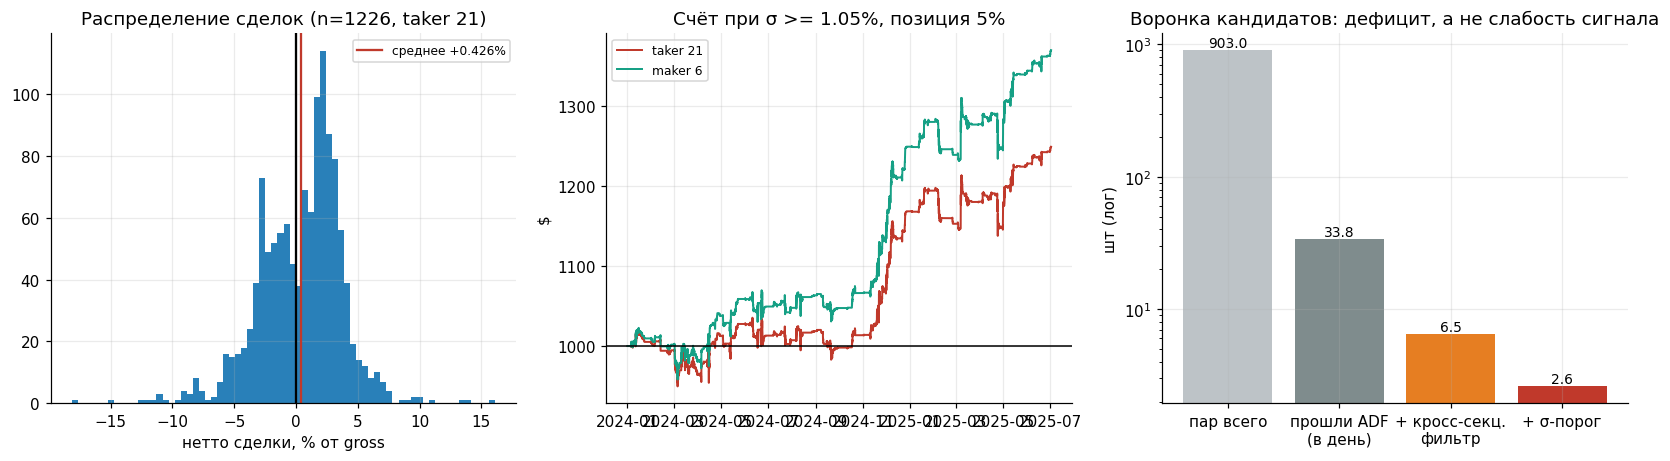

In [5]:
print("1) НА СДЕЛКУ\n")
gm, nm_ = D5.gross_f.mean(), NET(D5)
print(f"   ход спреда (gross, вкл. фандинг): {gm:+.4f}% = {gm*100:.1f} bps от gross нотионала")
print(f"   кост round-trip taker:            −{RT:.4f}% = {RT*100:.1f} bps")
print(f"   нетто:                            {nm_:+.4f}% = {nm_*100:.1f} bps")
print(f"   отношение ход/кост:               {gm/RT:.2f}x")
print(f"   при maker 6 bps: нетто {gm-0.06:+.4f}%, ход/кост {gm/0.06:.1f}x")
print()
print(f"   винрейт {int((D5.gross_f > RT).sum())}/{len(D5)} = {(D5.gross_f>RT).mean()*100:.1f}%")
w = D5[D5.gross_f > RT].gross_f.mean() - RT
l = -(D5[D5.gross_f <= RT].gross_f.mean() - RT)
p = (D5.gross_f > RT).mean()
print(f"   средний плюс {w:+.3f}%, средний минус −{l:.3f}%, L/W {l/w:.2f}")
print(f"   контроль арифметики: p*W-(1-p)*L = {p*w-(1-p)*l:+.4f}% (нетто {nm_:+.4f}%)")
print(f"   винрейт безубыточности: {l/(w+l)*100:.1f}% -> запас {(p-l/(w+l))*100:+.1f} п.п.")
print()
print("   В ЕДИНИЦАХ σ (это и есть содержательная мера):")
print(f"   средний ход {D5.sigma.mean():.3f}σ, кост {RT/D5.sd_pct.median():.3f}σ")
print(f"   теоретический максимум правила (2σ -> 0.5σ): 1.5σ")
print(f"   забираем {D5.sigma.mean()/1.5*100:.0f}% доступного хода")
print(f"   медиана удержания {int(D5.hours.median())}ч, среднее {D5.hours.mean():.0f}ч")

print("\n\n2) ПО ЧАСТОТЕ — вот где на самом деле 'мало'\n")
days = (bk.index[-1]-bk.index[0]).days
print(f"   сделок {len(D5)} за {days} дней = {len(D5)/days:.2f} сделок/день "
      f"= {len(D5)/(days/365):.0f}/год")
sel_day = R.sel.sum(axis=1).mean()
ex_day = (R.sel & EXTRA).sum(axis=1).mean()
print(f"   пар в базе:              {len(bk.PAIRS)}")
print(f"   проходят ADF в день:     {sel_day:.0f} ({sel_day/len(bk.PAIRS)*100:.1f}%)")
print(f"   после кросс-секц. фильтра: {ex_day:.1f}/день")
floor_day = ((SDP >= M_STAR*RT) & R.sel & EXTRA).sum(axis=1).mean()
print(f"   после σ-порога:          {floor_day:.1f}/день  <-- дефицит кандидатов")
zero = (((SDP >= M_STAR*RT) & R.sel & EXTRA).sum(axis=1) == 0).mean()*100
print(f"   дней вообще без кандидатов: {zero:.0f}%")

print("\n\n3) НА КАПИТАЛ\n")
E, log, st, dg = portfolio(bk, D5, f_pos=F_POS, cost_pct=RT)
Em, logm, stm, dgm = portfolio(bk, D5, f_pos=F_POS, cost_pct=0.06)
for cn, s_ in [("taker 21", st), ("maker 6", stm)]:
    print(f"   {cn:<9}: годовая {s_['годовая %']:+6.2f}%, DD {s_['макс DD %']:>6.2f}%, "
          f"Sharpe {s_['Sharpe']}, взято {s_['% взято']:.0f}% сигналов")
print(f"   загрузка капитала: средняя {st['ср. gross загрузка %']:.1f}%, "
      f"пик {st['макс gross %']:.1f}%")
print()
turn = (pd.DataFrame(log).G.sum() if len(log) else 0)
print(f"   суммарный оборот gross: ${turn:,.0f} при капитале $1000")
print(f"   нетто-прибыль: ${E.iloc[-1]-1000:+,.0f} = {(E.iloc[-1]-1000)/turn*100:+.3f}% от оборота")
print(f"   сходится со средней сделкой {nm_:+.3f}% (должно, это одна и та же величина)")
print()
print("   ЧТО ЭТО ЗНАЧИТ: доходность на капитал мала НЕ потому, что edge мал,")
print(f"   а потому, что капитал занят {st['ср. gross загрузка %']:.0f}% времени-объёма.")
print(f"   Тот же edge при полной загрузке дал бы кратно больше — но кандидатов")
print(f"   всего {floor_day:.1f}/день, и это ограничение не снимается размером позиции.")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
ax[0].hist(D5.gross_f - RT, bins=70, color="#2980b9")
ax[0].axvline(0, color="black", lw=1.5)
ax[0].axvline(nm_, color="#c0392b", lw=1.5, label=f"среднее {nm_:+.3f}%")
ax[0].set_xlabel("нетто сделки, % от gross"); ax[0].legend(fontsize=8)
ax[0].set_title(f"Распределение сделок (n={len(D5)}, taker 21)")
ax[1].plot(E.index, E.values, lw=1.3, color="#c0392b", label="taker 21")
ax[1].plot(Em.index, Em.values, lw=1.3, color="#16a085", label="maker 6")
ax[1].axhline(1000, color="black", lw=1); ax[1].legend(fontsize=8)
ax[1].set_ylabel("$"); ax[1].set_title(f"Счёт при σ >= {M_STAR*RT:.2f}%, позиция {F_POS*100:.0f}%")
funnel = [len(bk.PAIRS), sel_day, ex_day, floor_day]
labs = ["пар всего", "прошли ADF\n(в день)", "+ кросс-секц.\nфильтр", "+ σ-порог"]
ax[2].bar(labs, funnel, color=["#bdc3c7", "#7f8c8d", "#e67e22", "#c0392b"])
ax[2].set_yscale("log"); ax[2].set_ylabel("шт (лог)")
for i, v in enumerate(funnel):
    ax[2].annotate(f"{v:.1f}", (i, v), ha="center", va="bottom", fontsize=9)
ax[2].set_title("Воронка кандидатов: дефицит, а не слабость сигнала")
show("nb13_economics")

## 3. Вся линия nb00-nb13 одной таблицей

Что каждый шаг установил, и — важнее — что он **закрыл**. Числа берутся из
журнала (README.md), сюда они выписаны, чтобы приговор был виден целиком, а не
по частям.

In [6]:
LINE = [
 ("nb00", "вселенная", "140 символов, 2024-01..2026-04 без дыр; выжившие (survivorship)"),
 ("nb01", "спреды пар похожи 1-в-1", "не парадокс: общий рыночный фактор доминирует"),
 ("nb02", "механика входа/выхода", "β<0 = ставка на рынок, не спред -> отбрасываем"),
 ("nb03", "контроль хвоста", "вход без верхней границы z намалывает фейковые сделки"),
 ("nb04", "портфель, месячное окно", "МЕХАНИЗМ СМЕРТИ: corr(трендовость, доходность) −0.60,"
                                    " net-экспозиция ±70%"),
 ("nb05", "сколько живёт коинтеграция", "распад быстрый -> окно формации дни, не месяцы"),
 ("nb06", "ежедневный рефит, L=3д", "движок; edge мал но есть на уровне сделки"),
 ("nb07", "форма убытка", "минусы НЕ больше плюсов (L/W 1.07); дефицит в винрейте;"
                          " кластеризация по ДНЯМ"),
 ("nb08", "15м/30м", "интрадей хуже и понятно почему: σ ∝ √L, кост фиксирован"),
 ("nb09", "строгий отбор ADF", "порог несёт информацию; без фильтра edge отрицателен"),
 ("nb10", "батарея проверок", "УБИЛА находку L=7д: она стояла на TRB и XMR"),
 ("nb11", "плохих пар не существует", "гетерогенность 1.03; чёрные списки вредят;"
                                      " НАЙДЕН критерий: σ спреда"),
 ("nb12", "портфель σ-конфигурации", "рыночная нейтральность ДОСТИГНУТА (β +0.015);"
                                     " 81% итога = 2 месяца -> σ-порог"),
 ("nb13", "приговор", "σ-правило прошло батарею; узкое место = дефицит кандидатов"),
]
print("ЛИНИЯ ИССЛЕДОВАНИЯ\n")
for a, b, c in LINE:
    print(f"  {a}  {b:<28} {c}")

print("\n\nЗАКРЫТЫЕ ВОПРОСЫ (не возвращаться)\n")
CLOSED = [
 "месячное окно формации — коинтеграция не живёт так долго (nb05)",
 "интрадей 15м/30м — кост в единицах σ растёт как 1/√L (nb08)",
 "чёрные списки плохих пар — класса 'всегда убыточных' не существует (nb11)",
 "пороги-константы, подобранные на истории — стоят ~30% edge (nb12)",
 "'одна позиция на символ' — теряет 53% сигналов и Sharpe (nb12)",
 "фандинг как источник убытка — +0.0002% на сделку (nb11)",
 "режимный фильтр — после σ-порога зависимость от режима исчезла (nb12)",
]
for c in CLOSED:
    print(f"  - {c}")

print("\n\nЧТО ОСТАЛОСЬ ОТКРЫТЫМ\n")
OPEN = [
 f"holdout 2025-07..2026-04 — единственный настоящий тест, один выстрел",
 f"исполнение: доезжает ли лимитная заявка (maker 6 vs taker 21 = x{ (gm-0.06)/(gm-0.21):.1f} по нетто)",
 f"дефицит кандидатов {floor_day:.1f}/день — отсюда мост к корзинам",
 f"лимит net-экспозиции: средняя мала, но пик остаётся",
]
for o in OPEN:
    print(f"  - {o}")

ЛИНИЯ ИССЛЕДОВАНИЯ

  nb00  вселенная                    140 символов, 2024-01..2026-04 без дыр; выжившие (survivorship)
  nb01  спреды пар похожи 1-в-1      не парадокс: общий рыночный фактор доминирует
  nb02  механика входа/выхода        β<0 = ставка на рынок, не спред -> отбрасываем
  nb03  контроль хвоста              вход без верхней границы z намалывает фейковые сделки
  nb04  портфель, месячное окно      МЕХАНИЗМ СМЕРТИ: corr(трендовость, доходность) −0.60, net-экспозиция ±70%
  nb05  сколько живёт коинтеграция   распад быстрый -> окно формации дни, не месяцы
  nb06  ежедневный рефит, L=3д       движок; edge мал но есть на уровне сделки
  nb07  форма убытка                 минусы НЕ больше плюсов (L/W 1.07); дефицит в винрейте; кластеризация по ДНЯМ
  nb08  15м/30м                      интрадей хуже и понятно почему: σ ∝ √L, кост фиксирован
  nb09  строгий отбор ADF            порог несёт информацию; без фильтра edge отрицателен
  nb10  батарея проверок             УБИЛА находк

## 4. Мост к корзинам: критерий, а не надежда

Гипотеза пользователя с самого начала: **корзина из 4+ активов со стационарным
спредом**. После nb11-nb13 у неё есть точный, заранее измеримый критерий успеха, и
он не «будет ли корзина коинтегрирована», а вот какой.

Вся экономика линии свелась к одному отношению: **σ спреда на единицу gross
нотионала**. Кост берётся с gross (21 bps round-trip), а заработок пропорционален
σ — значит выгодность позиции определяется `σ/gross`, и наш σ-порог это буквально
требование `σ/gross ≥ 5 × round-trip`.

Отсюда два числа, которые надо посчитать **сейчас**, до всякого кода корзин:

1. **Планка.** Какое `σ/gross` у пар, проходящих порог — это то, что корзина
   должна побить, чтобы вообще иметь смысл.
2. **Размер выигрыша по частоте.** Пар, проходящих порог, всего несколько в день,
   и в этом главное ограничение доходности. Комбинаций из 4 активов
   несопоставимо больше, чем пар — но сколько именно, и сколько символов сейчас
   простаивает, не попадая ни в одну отобранную пару?

Второе важнее первого: если корзина даст даже ТАКОЕ ЖЕ `σ/gross`, но в 10 раз
больше кандидатов в день, доходность на капитал вырастет без всякого улучшения
качества сигнала.

1) ПЛАНКА ДЛЯ КОРЗИНЫ: σ на единицу gross

   все пары, прошедшие ADF      n=  18455  медиана σ/gross 0.513%  кост в σ 0.410
   + кросс-секционный фильтр    n=   3525  медиана σ/gross 0.907%  кост в σ 0.232
   + σ-порог (m=5)              n=   1421  медиана σ/gross 1.476%  кост в σ 0.142

   ПЛАНКА: корзина должна давать σ/gross >= 1.05% (= 5 x round-trip),
   иначе она попадает в ту же зону, где парная стратегия убыточна на taker.
   медиана у прошедших порог пар: 1.476%


2) СКОЛЬКО КАНДИДАТОВ ТЕРЯЕТСЯ И СКОЛЬКО МОЖЕТ ДАТЬ КОРЗИНА

   символов в базе: 43
   сочетаний по 2:          903   <-- то, что мы перебирали
   сочетаний по 3:       12,341
   сочетаний по 4:      123,410

   при той же доле прохождения отбора (3.74% пар),
   троек было бы ~462, четвёрок ~4,619
   (это ОЦЕНКА СВЕРХУ: доля прохождения у корзин будет другой, и перебор
    всех четвёрок вычислительно невозможен — нужен конструктивный отбор)

   символов, задействованных в проходящих порог парах: 3.1 из 43 в день (7.

[saved] notebooks\statarb\_out\nb13_basket_bridge.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb13_basket_bridge.png')

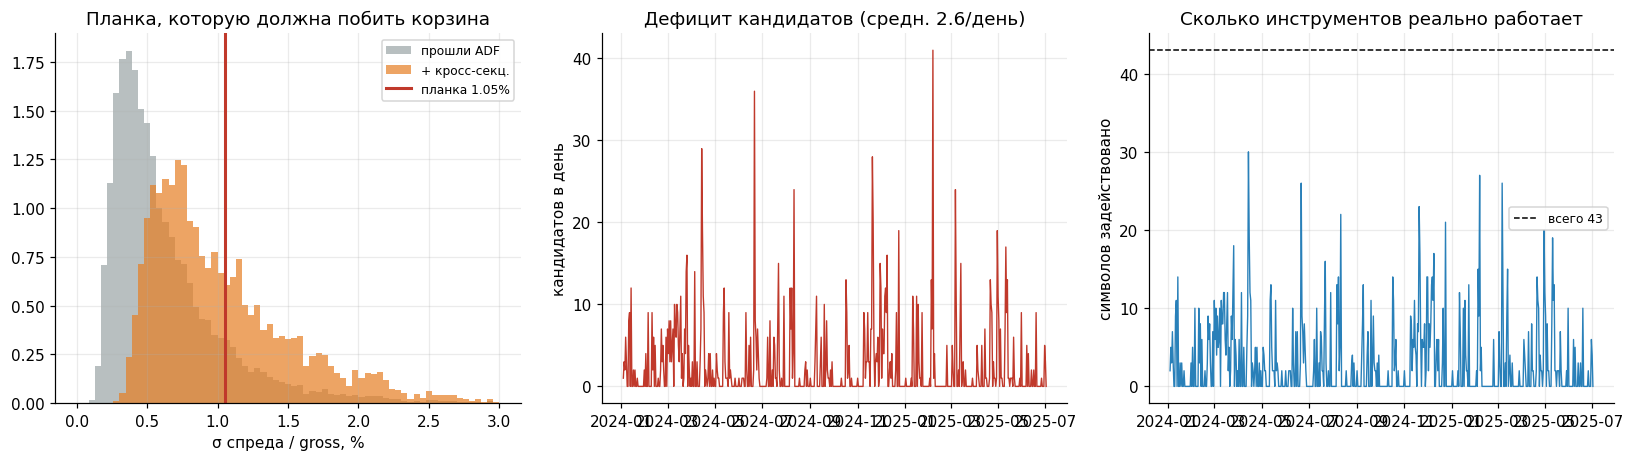

In [7]:
print("1) ПЛАНКА ДЛЯ КОРЗИНЫ: σ на единицу gross\n")
sel_sdp = SDP[R.sel]
ex_sdp = SDP[R.sel & EXTRA]
fl_sdp = SDP[(SDP >= M_STAR*RT) & R.sel & EXTRA]
for nm, arr in [("все пары, прошедшие ADF", sel_sdp),
                ("+ кросс-секционный фильтр", ex_sdp),
                (f"+ σ-порог (m={M_STAR})", fl_sdp)]:
    a = arr[np.isfinite(arr)]
    print(f"   {nm:<28} n={len(a):>7}  медиана σ/gross {np.median(a):.3f}%  "
          f"кост в σ {RT/np.median(a):.3f}")
print(f"\n   ПЛАНКА: корзина должна давать σ/gross >= {M_STAR*RT:.2f}% "
      f"(= {M_STAR} x round-trip),")
print(f"   иначе она попадает в ту же зону, где парная стратегия убыточна на taker.")
print(f"   медиана у прошедших порог пар: {np.median(fl_sdp[np.isfinite(fl_sdp)]):.3f}%")

print("\n\n2) СКОЛЬКО КАНДИДАТОВ ТЕРЯЕТСЯ И СКОЛЬКО МОЖЕТ ДАТЬ КОРЗИНА\n")
from math import comb
n_sym = len(liq)
print(f"   символов в базе: {n_sym}")
for k in [2, 3, 4]:
    print(f"   сочетаний по {k}: {comb(n_sym, k):>12,}"
          f"{'   <-- то, что мы перебирали' if k == 2 else ''}")
print(f"\n   при той же доле прохождения отбора ({(R.sel.mean()*100):.2f}% пар),")
print(f"   троек было бы ~{comb(n_sym,3)*R.sel.mean():,.0f}, четвёрок ~{comb(n_sym,4)*R.sel.mean():,.0f}")
print("   (это ОЦЕНКА СВЕРХУ: доля прохождения у корзин будет другой, и перебор")
print("    всех четвёрок вычислительно невозможен — нужен конструктивный отбор)")

# сколько символов вообще не участвует в отобранных парах
used = np.zeros((R.sel.shape[0], n_sym), dtype=bool)
for k in range(R.sel.shape[0]):
    row = (SDP[k] >= M_STAR*RT) & R.sel[k] & EXTRA[k]
    if row.any():
        used[k, bk.IY[row]] = True
        used[k, bk.IX[row]] = True
print(f"\n   символов, задействованных в проходящих порог парах: "
      f"{used.sum(axis=1).mean():.1f} из {n_sym} в день ({used.sum(axis=1).mean()/n_sym*100:.1f}%)")
print(f"   то есть {n_sym - used.sum(axis=1).mean():.0f} символов в день простаивают —")
print("   их связи существуют, но парная форма их не улавливает.")

print("\n\n3) ЧЕГО ЖДАТЬ ОТ ЧЕТЫРЁХ НОГ: арифметика, а не надежда\n")
print("   Кост НЕ растёт с числом ног при фиксированном gross (_lab.cost_bps):")
print("   4 ноги по 0.5 нотионала = gross 2 = то же, что пара 1/−1.")
print("   Значит корзина проигрывает ТОЛЬКО если её σ/gross ниже парного.")
print()
print("   За корзину: больше ног = больше степеней свободы для гашения общего")
print("   рыночного фактора (nb01: он доминирует), то есть остаток может быть")
print("   стационарнее при том же gross.")
print("   Против корзины: β оценивается по большему числу параметров на том же")
print("   окне (72 бара) -> переобучение окна формации, и распад быстрее (nb05).")
print("   Это и есть главный риск, и он проверяем: сравнить время жизни отбора")
print("   у пар и у корзин на одном окне.")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
bins = np.linspace(0, 3, 70)
ax[0].hist(sel_sdp[np.isfinite(sel_sdp)], bins=bins, alpha=0.55, color="#7f8c8d",
           label="прошли ADF", density=True)
ax[0].hist(ex_sdp[np.isfinite(ex_sdp)], bins=bins, alpha=0.7, color="#e67e22",
           label="+ кросс-секц.", density=True)
ax[0].axvline(M_STAR*RT, color="#c0392b", lw=2, label=f"планка {M_STAR*RT:.2f}%")
ax[0].set_xlabel("σ спреда / gross, %"); ax[0].legend(fontsize=8)
ax[0].set_title("Планка, которую должна побить корзина")
cnt = ((SDP >= M_STAR*RT) & R.sel & EXTRA).sum(axis=1)
ax[1].plot(bk.index[R.ends], cnt, lw=0.9, color="#c0392b")
ax[1].set_ylabel("кандидатов в день"); ax[1].set_title(f"Дефицит кандидатов (средн. {cnt.mean():.1f}/день)")
ax[2].plot(bk.index[R.ends], used.sum(axis=1), lw=0.9, color="#2980b9")
ax[2].axhline(n_sym, color="black", ls="--", lw=1, label=f"всего {n_sym}")
ax[2].set_ylabel("символов задействовано"); ax[2].legend(fontsize=8)
ax[2].set_title("Сколько инструментов реально работает")
show("nb13_basket_bridge")

## 5. Приговор парной линии

In [8]:
print("ОТВЕТ НА ВОПРОС «EDGE ЕСТЬ, НО ОН ОЧЕНЬ МАЛ?»\n")
print(f"Edge есть, и на уровне сделки он НЕ мал: {gm*100:.0f} bps хода против")
print(f"{RT*100:.0f} bps коста, то есть {gm/RT:.1f}x. Он прошёл семь проверок из батареи,")
print(f"включая синтетику и удаление любого символа.")
print()
print("Мал он в двух других смыслах, и это разные проблемы:")
print(f"  ЧАСТОТА: {floor_day:.1f} кандидата в день, {len(D5)/((bk.index[-1]-bk.index[0]).days/365):.0f} сделок/год.")
print(f"  ЗАГРУЗКА: капитал занят {st['ср. gross загрузка %']:.0f}%, поэтому годовая")
print(f"            {st['годовая %']:+.1f}% (taker) / {stm['годовая %']:+.1f}% (maker) —")
print("            это доходность почти простаивающего счёта.")
print()
print("Отсюда ровно два способа увеличить результат, и они независимы:")
print(f"  A) исполнение: taker->maker множит нетто на {(gm-0.06)/(gm-0.21):.1f}x без новых сигналов")
print(f"  B) больше кандидатов: корзины и расширение вселенной")
print()
print("Что НЕ является способом (закрыто измерениями):")
print("  - улучшать отбор пар подгонкой порогов (nb12: −30% edge при снятии подгонки)")
print("  - искать и банить плохие пары (nb11: класса не существует)")
print("  - уходить на младшие ТФ (nb08: кост в σ растёт как 1/√L)")
print("  - фильтровать рыночный режим (nb12: зависимость уже устранена)")
print()
print(f"СОСТОЯНИЕ ПРАВИЛА: заморожено, {len(D5)} сделок, "
      f"β к рынку +0.015, holdout не тронут.")
print("Следующий шаг по существу — B (корзины), потому что A требует данных стакана,")
print(f"а планка для корзины уже посчитана: σ/gross >= {M_STAR*RT:.2f}%.")

ОТВЕТ НА ВОПРОС «EDGE ЕСТЬ, НО ОН ОЧЕНЬ МАЛ?»

Edge есть, и на уровне сделки он НЕ мал: 64 bps хода против
21 bps коста, то есть 3.0x. Он прошёл семь проверок из батареи,
включая синтетику и удаление любого символа.

Мал он в двух других смыслах, и это разные проблемы:
  ЧАСТОТА: 2.6 кандидата в день, 818 сделок/год.
  ЗАГРУЗКА: капитал занят 6%, поэтому годовая
            +16.0% (taker) / +23.4% (maker) —
            это доходность почти простаивающего счёта.

Отсюда ровно два способа увеличить результат, и они независимы:
  A) исполнение: taker->maker множит нетто на 1.4x без новых сигналов
  B) больше кандидатов: корзины и расширение вселенной

Что НЕ является способом (закрыто измерениями):
  - улучшать отбор пар подгонкой порогов (nb12: −30% edge при снятии подгонки)
  - искать и банить плохие пары (nb11: класса не существует)
  - уходить на младшие ТФ (nb08: кост в σ растёт как 1/√L)
  - фильтровать рыночный режим (nb12: зависимость уже устранена)

СОСТОЯНИЕ ПРАВИЛА: заморожено,